In [1]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# Load the data

In [8]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [9]:
y.shape, tx.shape

((10000,), (10000, 2))

### NB: throughout this laboratory the data has the following format: 
  * there are **N = 10000** data entries
  * **y** represents the column vector containing weight information -- that which we wish to predict/the output (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,)**.
  * **tx** represents the matrix $\tilde{X}$ formed by laterally concatenating a column vector of 1s to the column vector of height information -- the input data (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,2)**.

# 1. Computing the Cost Function
Fill in the `compute_loss` function below:

In [ ]:
def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss by MSE
    size = y.shape[0]
    cost_function = (1/(2*size))*(y-tx@w).transpose()@(y-tx@w)
    # ***************************************************
    return cost_function

# 2. Grid Search

Fill in the function `grid_search()` below:

In [11]:
# from costs import *


def grid_search(y, tx, grid_w0, grid_w1):
    """Algorithm for grid search.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        grid_w0: numpy array of shape=(num_grid_pts_w0, ). A 1D array containing num_grid_pts_w0 values of parameter w0 to be tested in the grid search.
        grid_w1: numpy array of shape=(num_grid_pts_w1, ). A 1D array containing num_grid_pts_w1 values of parameter w1 to be tested in the grid search.

    Returns:
        losses: numpy array of shape=(num_grid_pts_w0, num_grid_pts_w1). A 2D array containing the loss value for each combination of w0 and w1
    """

    losses = np.zeros((len(grid_w0), len(grid_w1)))
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss for each combination of w0 and w1.
    for i in range(len(grid_w0)):
        for j in range(len(grid_w1)):
            losses[i,j] = compute_loss(y,tx,[grid_w0[i],grid_w1[j]])
    # ***************************************************
    return losses

Let us play with the grid search demo now!

Grid Search: loss*=18.793541019523104, w0*=71.42857142857142, w1*=15.306122448979579, execution time=0.207 seconds


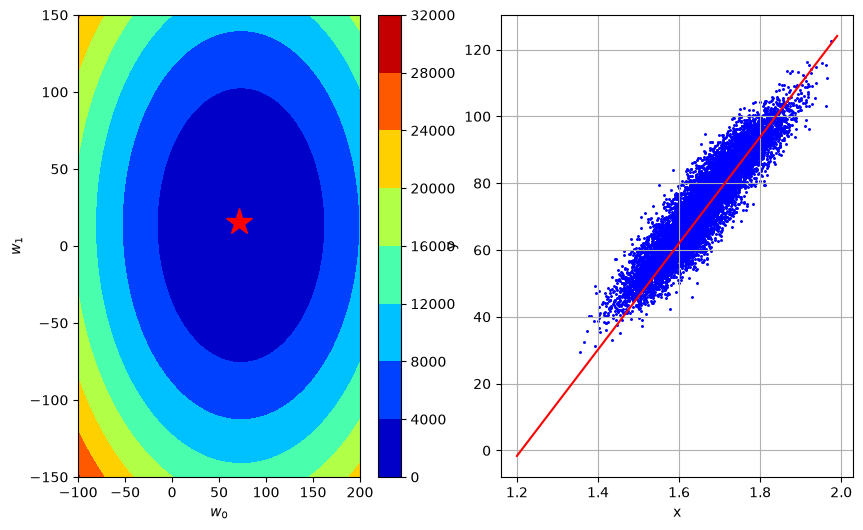

In [22]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=50)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving

# 3. Gradient Descent

Again, please fill in the functions `compute_gradient` below:

In [25]:
def compute_gradient(y, tx, w):
    """Computes the gradient at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        An numpy array of shape (2, ) (same shape as w), containing the gradient of the loss at w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute gradient vector
    #scalar
    size = y.shape[0]
    # error array shape = (N,)
    error = y - tx@w
    #gradient array shape = (2,) 
    gradient = -(1/size)*tx.T@error
    # ***************************************************
    return gradient 

Please fill in the functions `gradient_descent` below:

In [27]:
def gradient_descent(y, tx, initial_w, max_iters, gamma):
    """The Gradient Descent (GD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of GD
        ws: a list of length max_iters + 1 containing the model parameters as numpy arrays of shape (2, ),
            for each iteration of GD (as well as the final weights)
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: compute gradient and loss
        gradient = compute_gradient(y,tx,w)
        loss = compute_loss(y,tx,w)
        # ***************************************************
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: update w by gradient
        w = w - gamma*gradient
        # ***************************************************

        # store w and loss
        ws.append(w)
        losses.append(loss)
        print(
            "GD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

Test your gradient descent function through gradient descent demo shown below:

In [36]:
# from gradient_descent import *
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1

# Initialization
w_initial = np.array([100, 10])

# Start gradient descent.
start_time = datetime.datetime.now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=378.0473881987601, w0=97.3293922002105, w1=10.347971243498897
GD iter. 1/49: loss=309.14170313607315, w0=94.92584518039996, w1=10.66114536264791
GD iter. 2/49: loss=253.32809823529672, w0=92.76265286257049, w1=10.943002069882015
GD iter. 3/49: loss=208.11907826566818, w0=90.81577977652395, w1=11.19667310639271
GD iter. 4/49: loss=171.49977209026875, w0=89.06359399908207, w1=11.424977039252338
GD iter. 5/49: loss=141.83813408819535, w0=87.48662679938438, w1=11.630450578826006
GD iter. 6/49: loss=117.81220730651589, w0=86.06735631965645, w1=11.815376764442304
GD iter. 7/49: loss=98.35120661335544, w0=84.79001288790133, w1=11.981810331496975
GD iter. 8/49: loss=82.58779605189557, w0=83.6404037993217, w1=12.13160054184618
GD iter. 9/49: loss=69.81943349711297, w0=82.60575561960005, w1=12.266411731160462
GD iter. 10/49: loss=59.4770598277391, w0=81.67457225785056, w1=12.387741801543317
GD iter. 11/49: loss=51.099737155546265, w0=80.83650723227602, w1=12.496938864887888
G

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

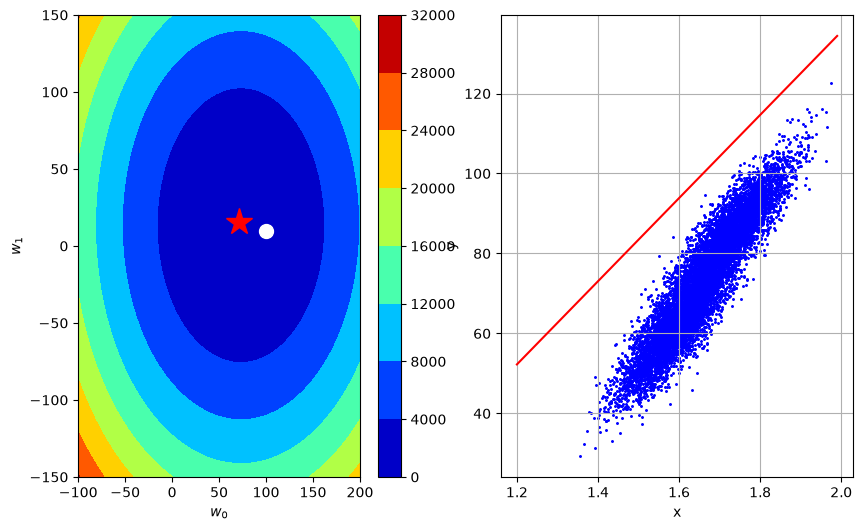

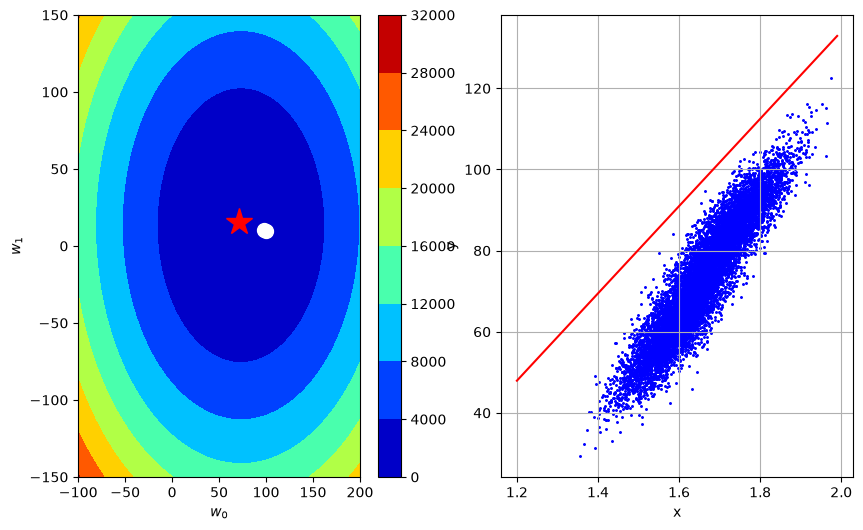

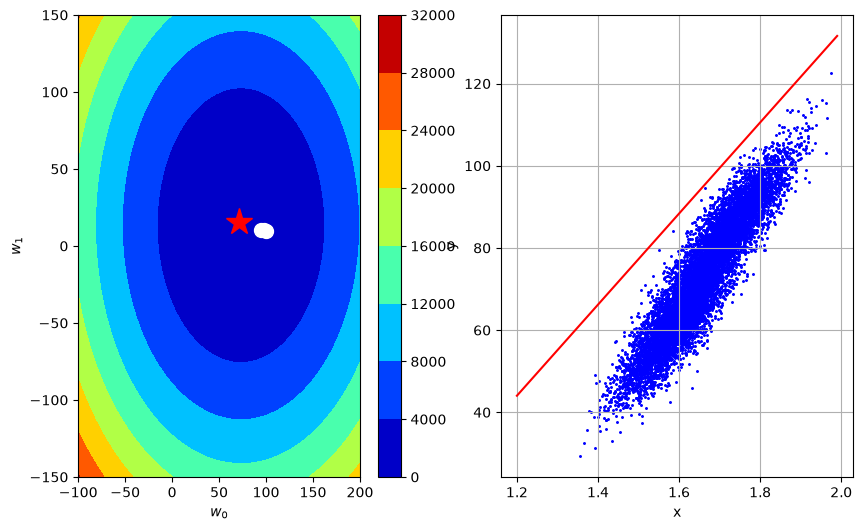

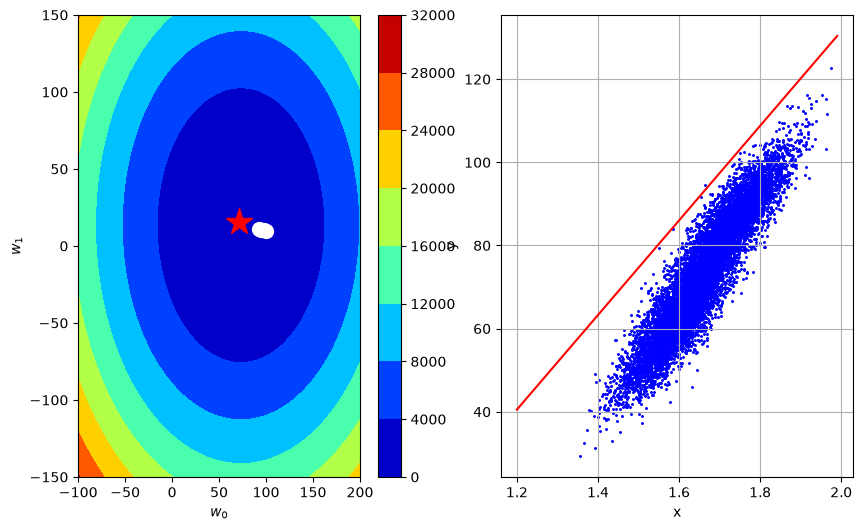

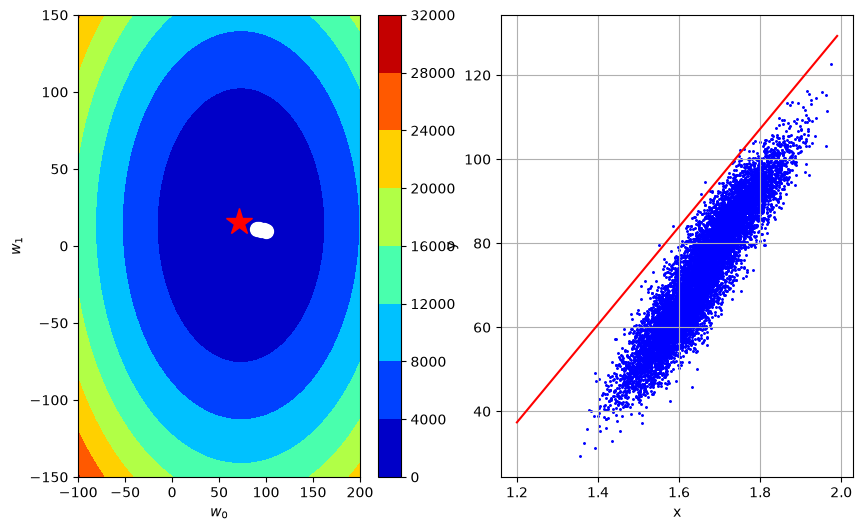

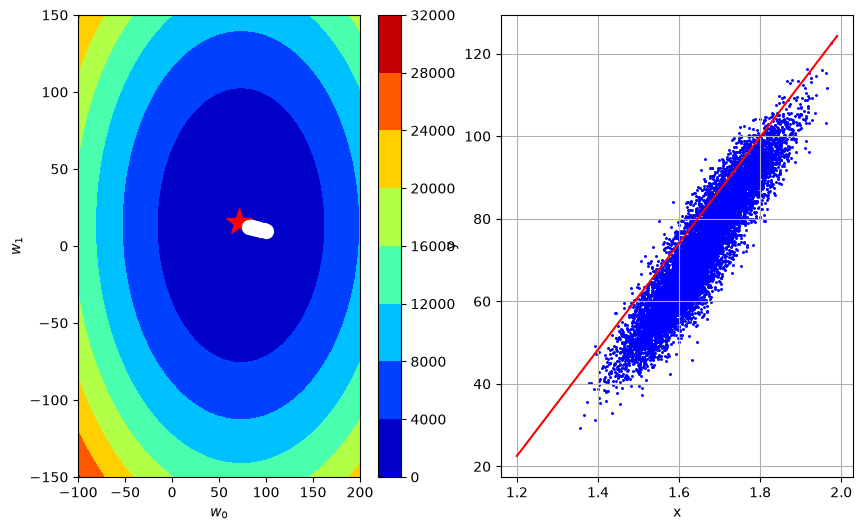

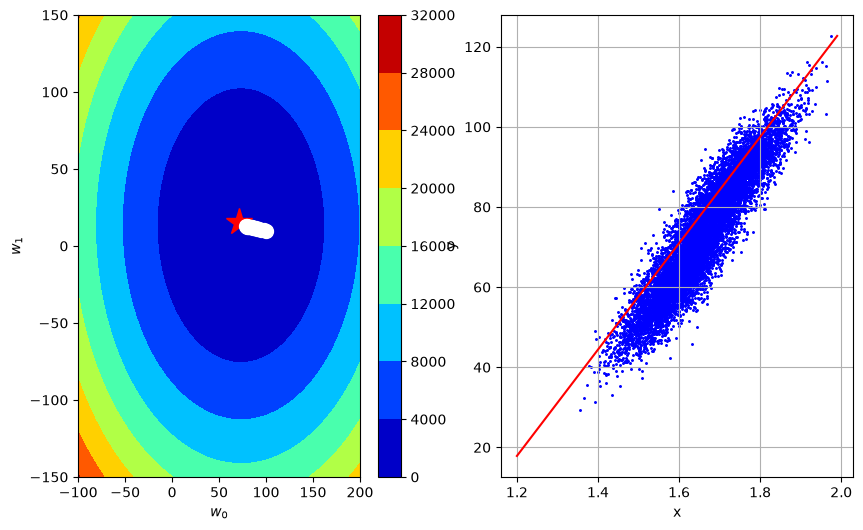

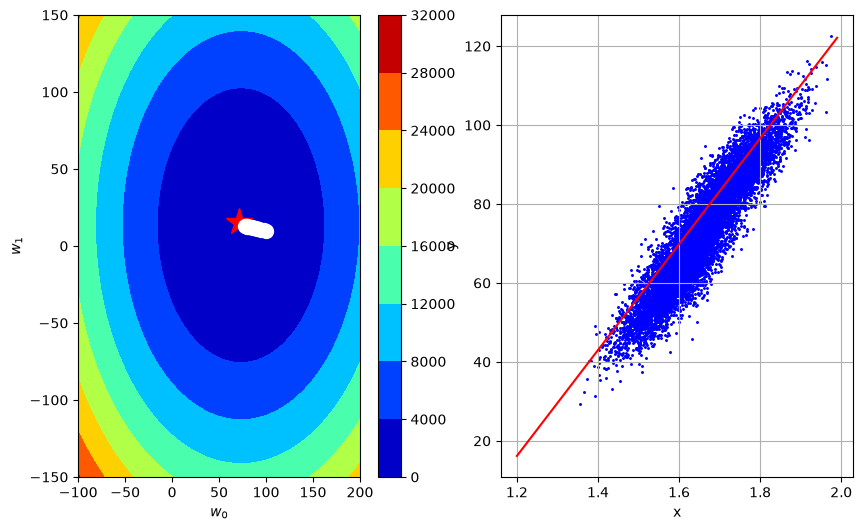

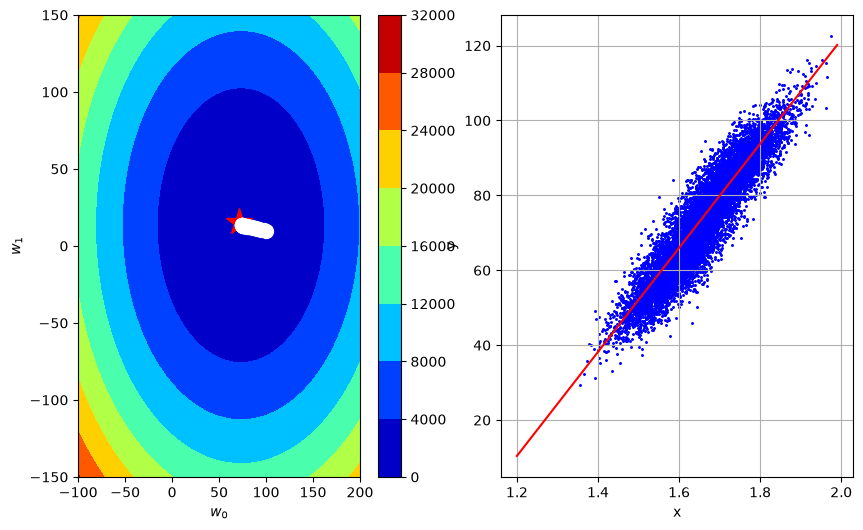

In [37]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

# 4. Stochastic gradient descent

In [39]:
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """

    # TODO: implement stochastic gradient computation. It's the same as the usual gradient.
    
    size = y.shape[0]
     # error array shape = (N,)
    error = y - tx@w
    #gradient array shape = (2,) 
    gradient = -(1/size)*tx.T@error
    return gradient 



def stochastic_gradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: implement stochastic gradient descent.
        y_B, tx_B = next(batch_iter(y,tx,batch_size))
        stoch_gradient = compute_stoch_gradient(y_B,tx_B,w)
        loss = compute_loss(y,tx,w)
        w = w - gamma * stoch_gradient
        losses.append(loss)
        ws.append(w)

        
        # ***************************************************

        print(
            "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [40]:
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=2792.236712759168, w0=5.911611435564908, w1=-3.8338911384026413
SGD iter. 1/49: loss=2435.454210859954, w0=16.330397570263667, w1=17.36478578437055
SGD iter. 2/49: loss=1645.3543431823646, w0=22.237857871738616, w1=11.37408131356511
SGD iter. 3/49: loss=1320.9635713206337, w0=26.540076173666254, w1=16.88066140193695
SGD iter. 4/49: loss=1114.130164681437, w0=32.187336503645774, w1=14.495257806560277
SGD iter. 5/49: loss=860.7772397407635, w0=36.469410105719405, w1=8.541892762002735
SGD iter. 6/49: loss=705.5992576338222, w0=39.59685191842462, w1=7.385090108543756
SGD iter. 7/49: loss=601.7043646320707, w0=42.210340959064695, w1=3.795724401039073
SGD iter. 8/49: loss=545.3702052193047, w0=42.901445481606146, w1=3.1375640220918806
SGD iter. 9/49: loss=530.7172192905672, w0=47.11779646517439, w1=4.688390817367033
SGD iter. 10/49: loss=396.6243298236429, w0=50.85073437884306, w1=5.325547833633473
SGD iter. 11/49: loss=300.4794233883021, w0=51.84620886239452, w1=4.40549

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

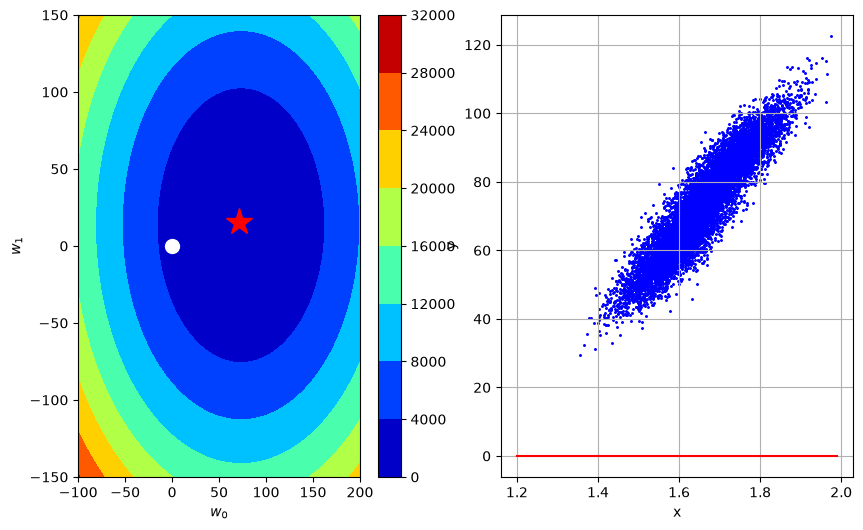

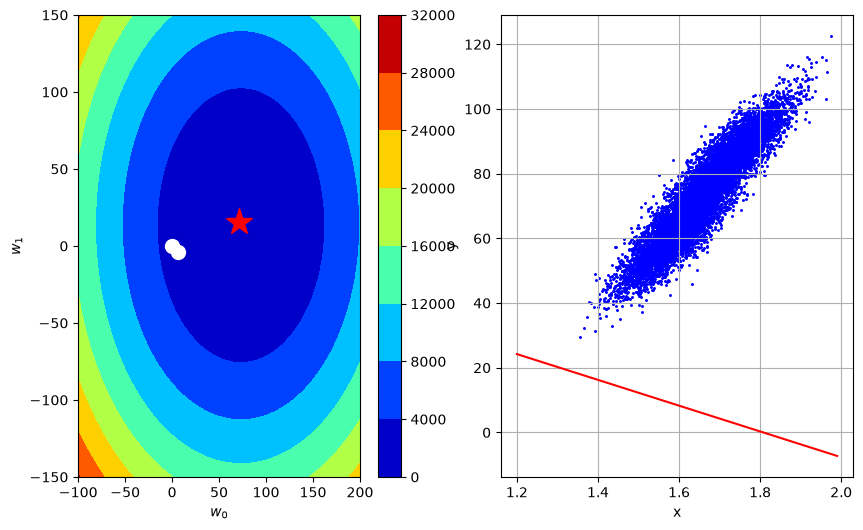

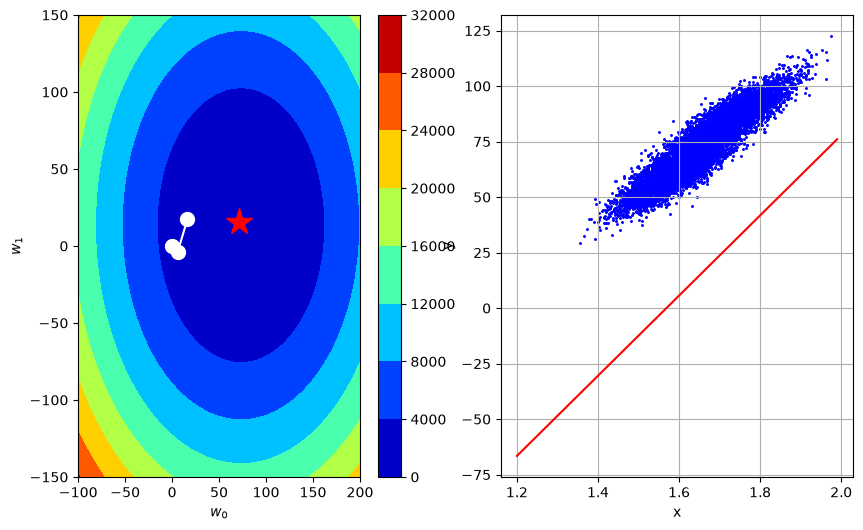

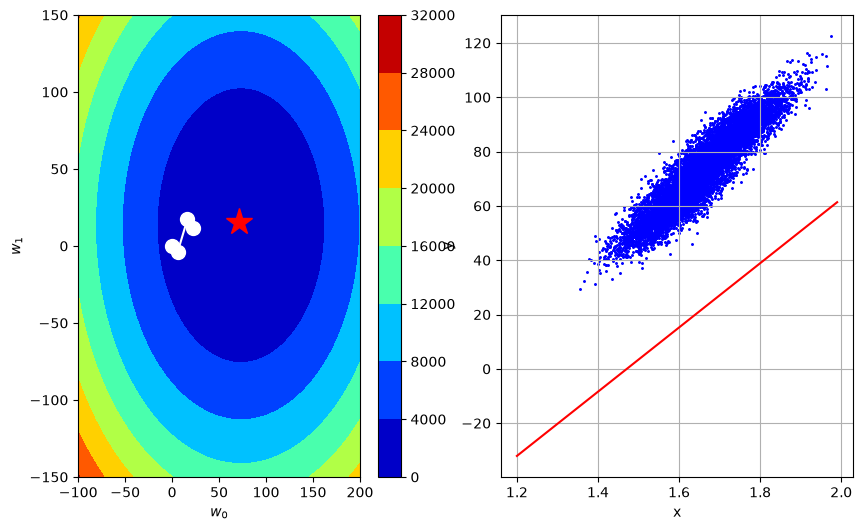

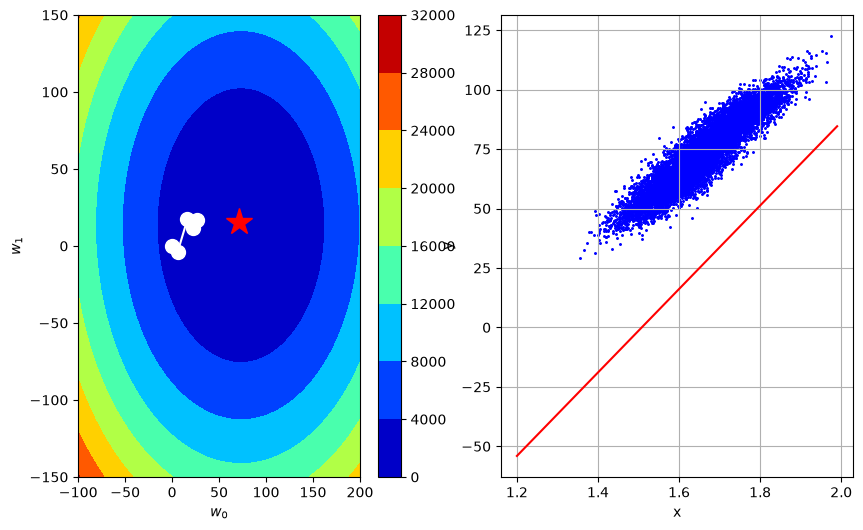

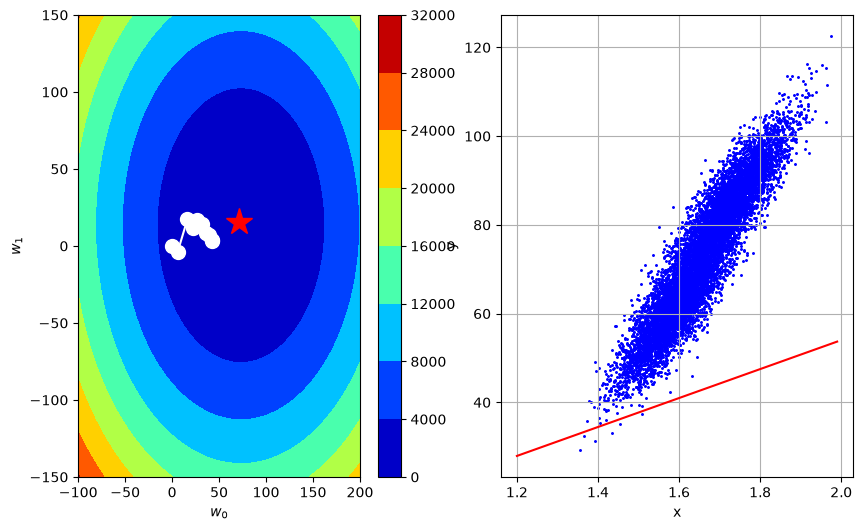

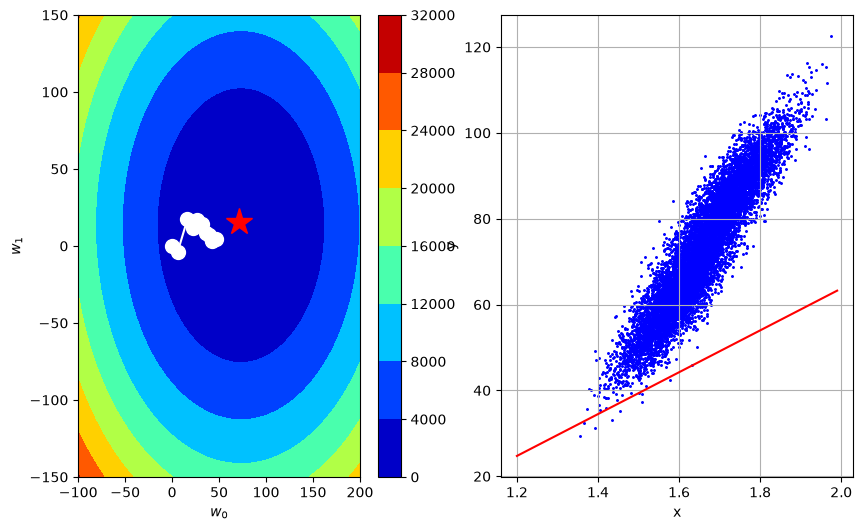

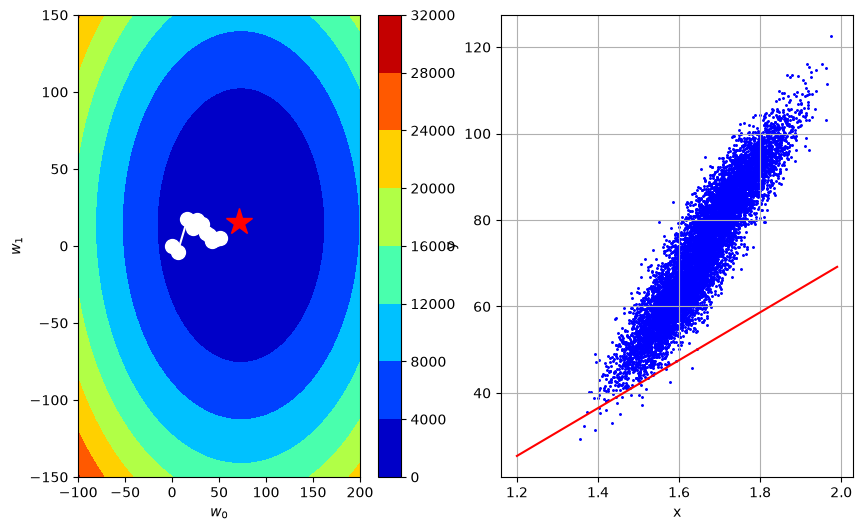

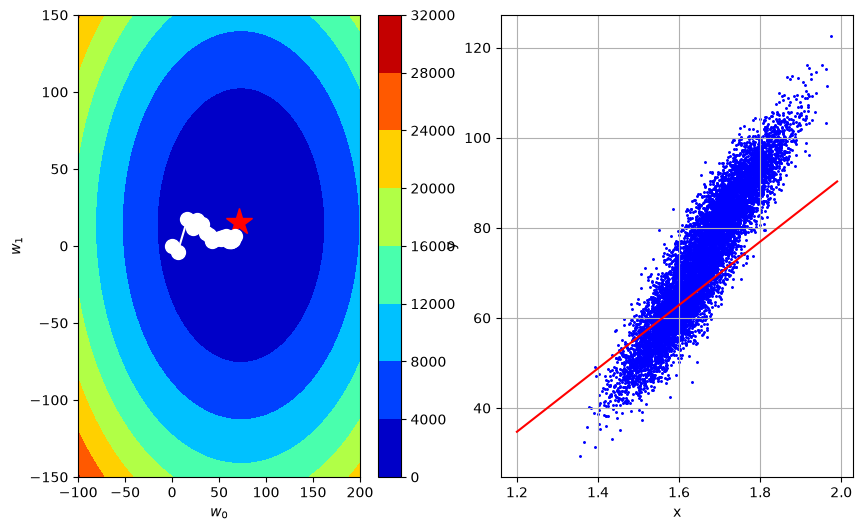

In [41]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

# 5. Effect of Outliers and MAE Cost Function

In [54]:
import datetime
from helpers import *

# ***************************************************
# INSERT YOUR CODE HERE

# TODO: reload the data by subsampling first, then by subsampling and adding outliers
height, weight, gender = load_data(sub_sample=False, add_outlier=True)
# ***************************************************

x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [55]:
y.shape, tx.shape

((10002,), (10002, 2))

In [56]:
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: fit the model to the subsampled data / subsampled data with outliers and visualize the cloud of points
#       and the model fit
gd_losses, gd_ws = gradient_descent(y,tx,w_initial,max_iters,gamma)
# ***************************************************


end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=2793.063324919039, w0=51.31194997183167, w1=9.375829281932656
GD iter. 1/49: loss=266.5853963287444, w0=66.70553496338117, w1=12.18857806651236
GD iter. 2/49: loss=39.2023827556181, w0=71.32361046084606, w1=13.032402701886305
GD iter. 3/49: loss=18.73791153403654, w0=72.7090331100855, w1=13.2855500924985
GD iter. 4/49: loss=16.896109124094245, w0=73.12465990485734, w1=13.361494309682161
GD iter. 5/49: loss=16.73034690719944, w0=73.24934794328888, w1=13.38427757483726
GD iter. 6/49: loss=16.71542830767891, w0=73.28675435481834, w1=13.39111255438379
GD iter. 7/49: loss=16.714085633722057, w0=73.29797627827718, w1=13.393163048247748
GD iter. 8/49: loss=16.713964793065944, w0=73.30134285531483, w1=13.393778196406936
GD iter. 9/49: loss=16.713953917406894, w0=73.30235282842612, w1=13.393962740854693
GD iter. 10/49: loss=16.713952938597576, w0=73.30265582035952, w1=13.39401810418902
GD iter. 11/49: loss=16.71395285050474, w0=73.30274671793954, w1=13.394034713189317
GD ite

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

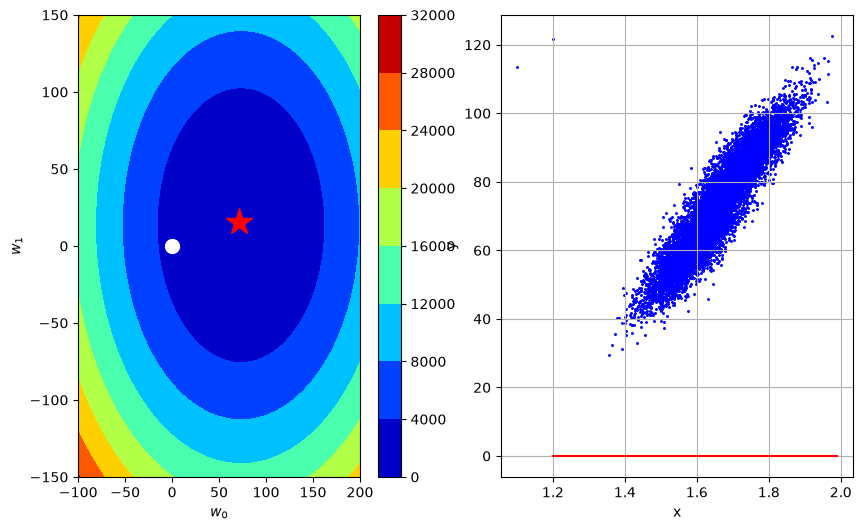

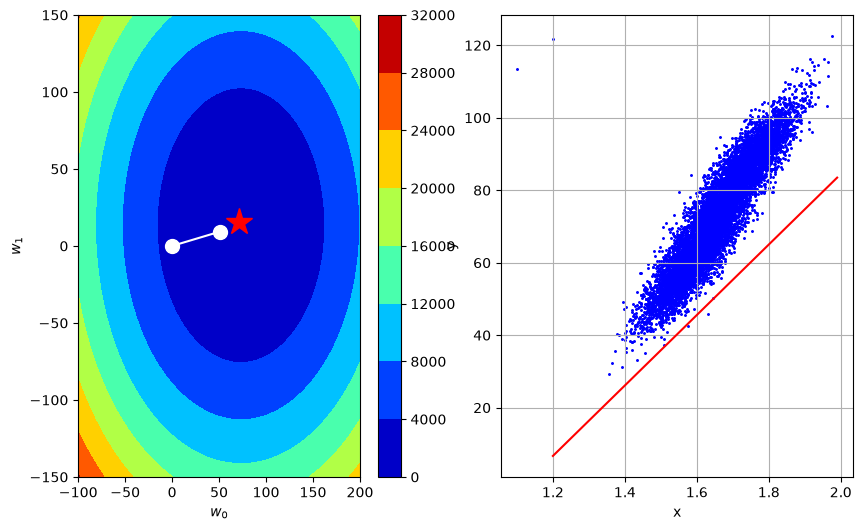

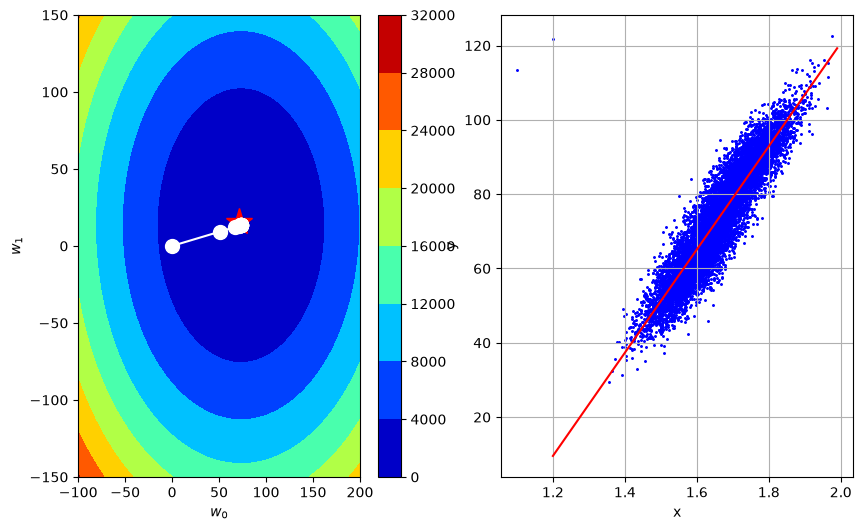

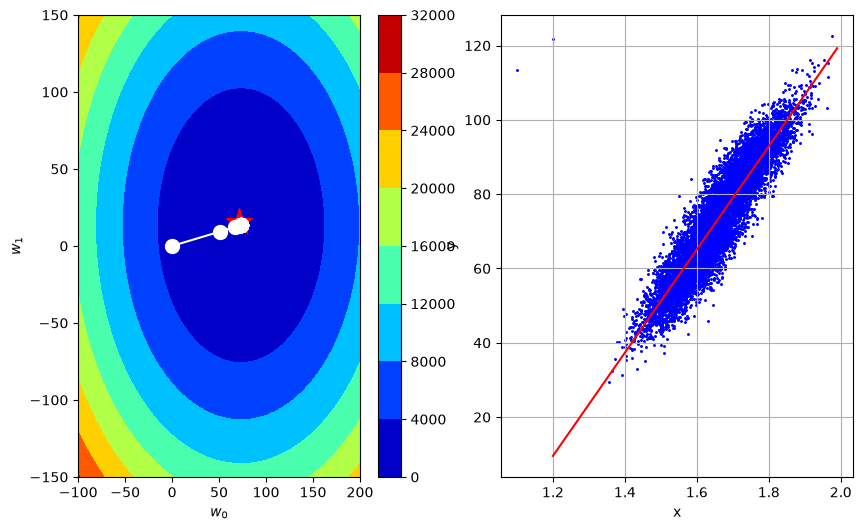

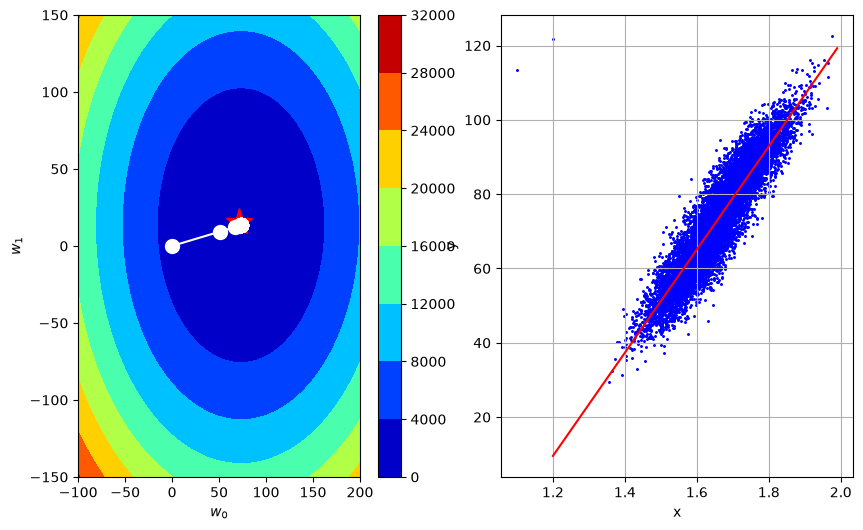

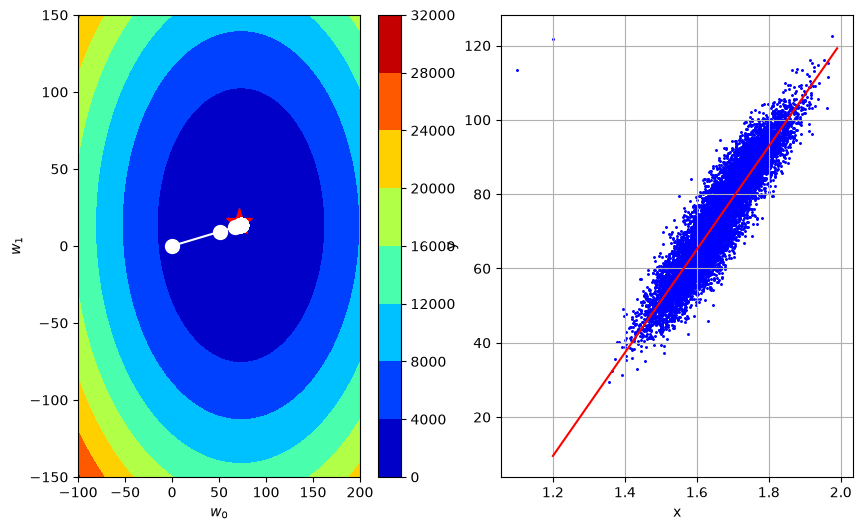

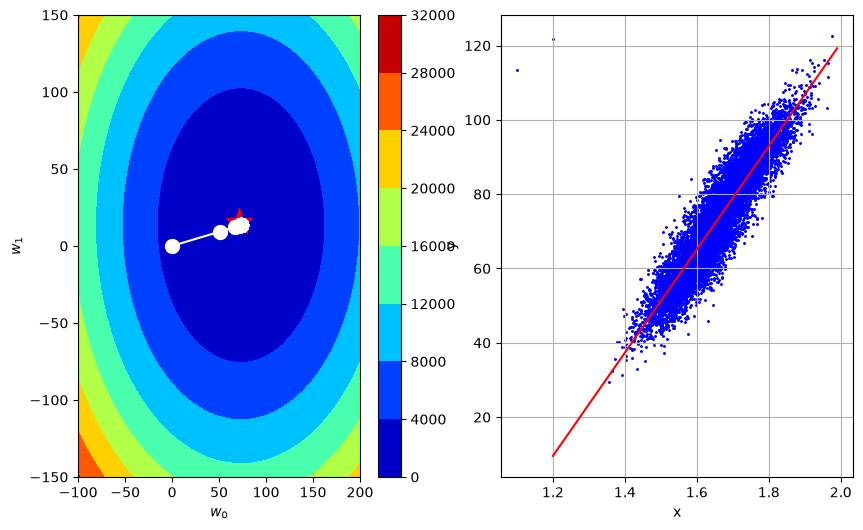

In [57]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

# 6. Subgradient descent

In [58]:
def compute_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute subgradient gradient vector for MAE
    N = y.shape[0]
    e = y - tx@w
    gradient_e = -tx.T
    subdifferential = np.sign(e)
    subgradient = gradient_e@subdifferential

    # ***************************************************
    return (1/N)*subgradient

In [67]:
def compute_loss_MAE(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss by MSE
    size = y.shape[0]
    cost_function = (1/size)*np.sum(np.abs(y-tx@w))
    # ***************************************************
    return cost_function

In [68]:
def subgradient_descent(y, tx, initial_w, max_iters, gamma):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: compute subgradient and loss
        subgradient = compute_subgradient_mae(y, tx, w)
        loss = compute_loss_MAE(y, tx, w)
        # ***************************************************
       
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: update w by subgradient
        w = w - gamma*subgradient
        # ***************************************************


        ws.append(w)
        losses.append(loss)
        print(
            "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

In [69]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subgd_losses, subgd_ws = subgradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubGD: execution time={t:.3f} seconds".format(t=exection_time))

SubGD iter. 0/499: loss=73.30278567404525, w0=0.7, w1=2.0662003068968717e-16
SubGD iter. 1/499: loss=72.60278567404525, w0=1.4, w1=4.1324006137937435e-16
SubGD iter. 2/499: loss=71.90278567404523, w0=2.0999999999999996, w1=6.198600920690615e-16
SubGD iter. 3/499: loss=71.20278567404524, w0=2.8, w1=8.264801227587487e-16
SubGD iter. 4/499: loss=70.50278567404526, w0=3.5, w1=1.0331001534484358e-15
SubGD iter. 5/499: loss=69.80278567404525, w0=4.2, w1=1.2397201841381228e-15
SubGD iter. 6/499: loss=69.10278567404525, w0=4.9, w1=1.44634021482781e-15
SubGD iter. 7/499: loss=68.40278567404523, w0=5.6000000000000005, w1=1.652960245517497e-15
SubGD iter. 8/499: loss=67.70278567404524, w0=6.300000000000001, w1=1.859580276207184e-15
SubGD iter. 9/499: loss=67.00278567404526, w0=7.000000000000001, w1=2.066200306896871e-15
SubGD iter. 10/499: loss=66.30278567404525, w0=7.700000000000001, w1=2.2728203375865582e-15
SubGD iter. 11/499: loss=65.60278567404525, w0=8.4, w1=2.4794403682762453e-15
SubGD ite

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

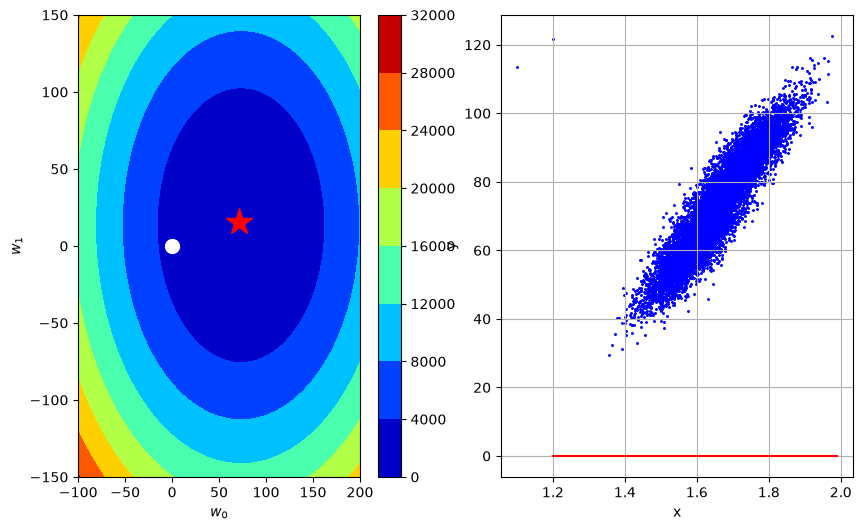

In [70]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subgd_losses,
        subgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subgd_ws)))

# Stochastic Subgradient Descent

**NB** for the computation of the subgradient you can reuse the `compute_subgradient` method that you implemented above, just making sure that you pass in a minibatch as opposed to the full data.

In [71]:
def stochastic_subgradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """Compute a stochastic subgradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic subgradient
        max_iters: a scalar denoting the total number of iterations of SubSGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubSGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubSGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: implement stochastic subgradient descent.
        y_B, tx_B = next(batch_iter(y, tx, batch_size))
        loss = compute_loss_MAE(y_B, tx_B, w)
        subgradient = compute_subgradient_mae(y_B, tx_B,w)
        w = w - gamma * subgradient
        ws.append(w)
        losses.append(loss)
       
        # ***************************************************
        

        print(
            "SubSGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [72]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subsgd_losses, subsgd_ws = stochastic_subgradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubSGD: execution time={t:.3f} seconds".format(t=exection_time))

SubSGD iter. 0/499: loss=79.25887713880783, w0=0.7, w1=0.14745114485134694
SubSGD iter. 1/499: loss=84.62695676392643, w0=1.4, w1=0.5200181749545559
SubSGD iter. 2/499: loss=70.18261986241377, w0=2.0999999999999996, w1=0.1889728031473113
SubSGD iter. 3/499: loss=74.99914195706505, w0=2.8, w1=0.5666567434658845
SubSGD iter. 4/499: loss=72.86992071225197, w0=3.5, w1=1.1061517480272762
SubSGD iter. 5/499: loss=62.86136837456453, w0=4.2, w1=0.43609827659868394
SubSGD iter. 6/499: loss=88.1559392405749, w0=4.9, w1=1.3758889156740648
SubSGD iter. 7/499: loss=79.56005427980041, w0=5.6000000000000005, w1=1.5967603916334396
SubSGD iter. 8/499: loss=64.69427157592925, w0=6.300000000000001, w1=1.7299388337970665
SubSGD iter. 9/499: loss=87.88100558462283, w0=7.000000000000001, w1=2.919864067901554
SubSGD iter. 10/499: loss=62.89427065906839, w0=7.700000000000001, w1=2.463794132543097
SubSGD iter. 11/499: loss=75.94596499119, w0=8.4, w1=3.162401166783079
SubSGD iter. 12/499: loss=58.48150548791469

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

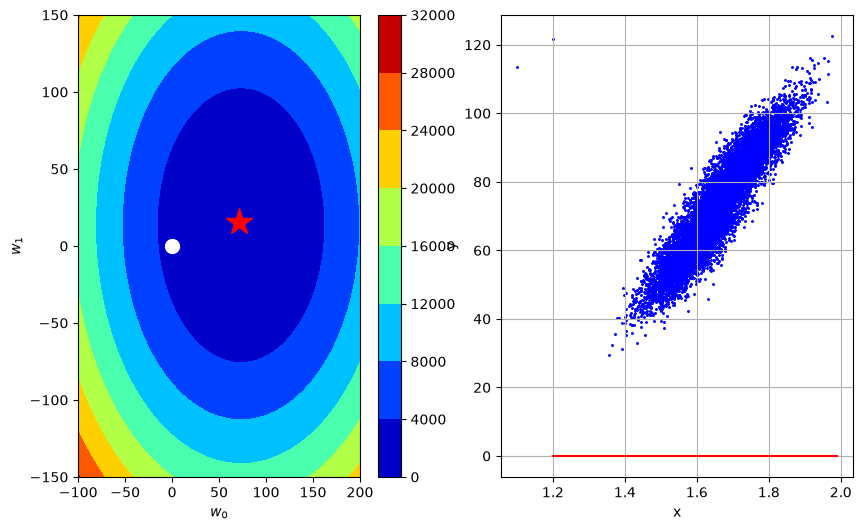

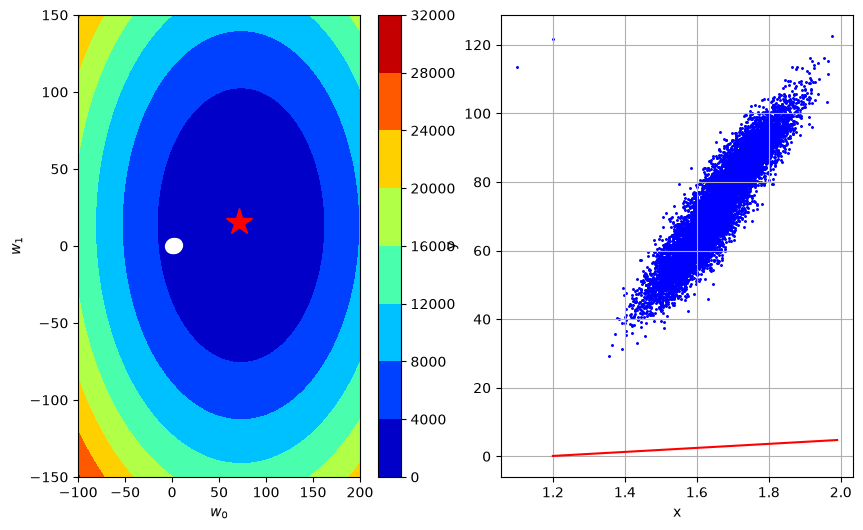

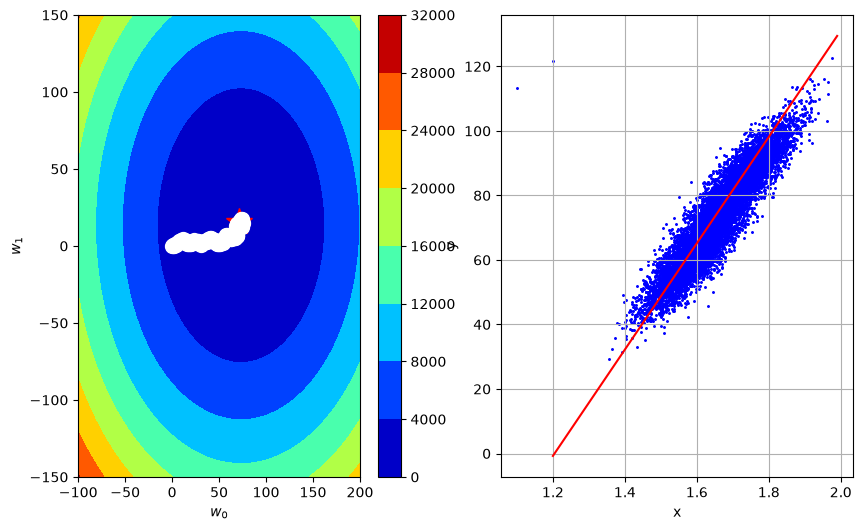

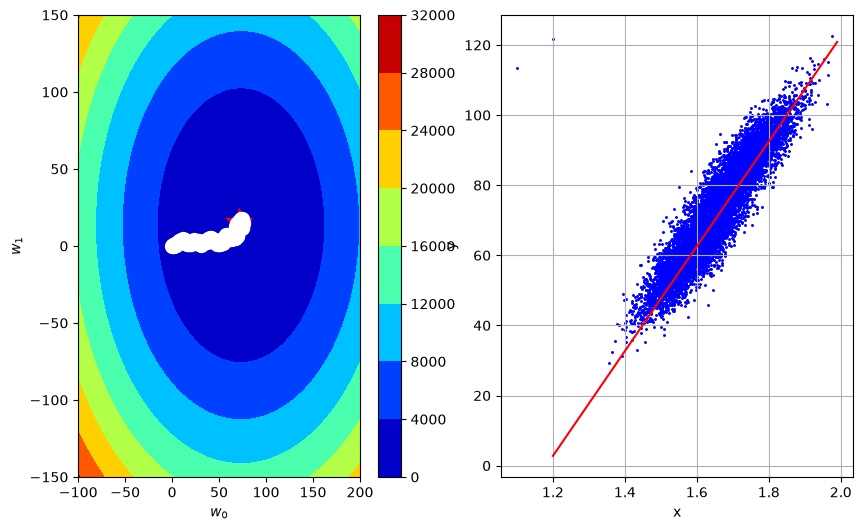

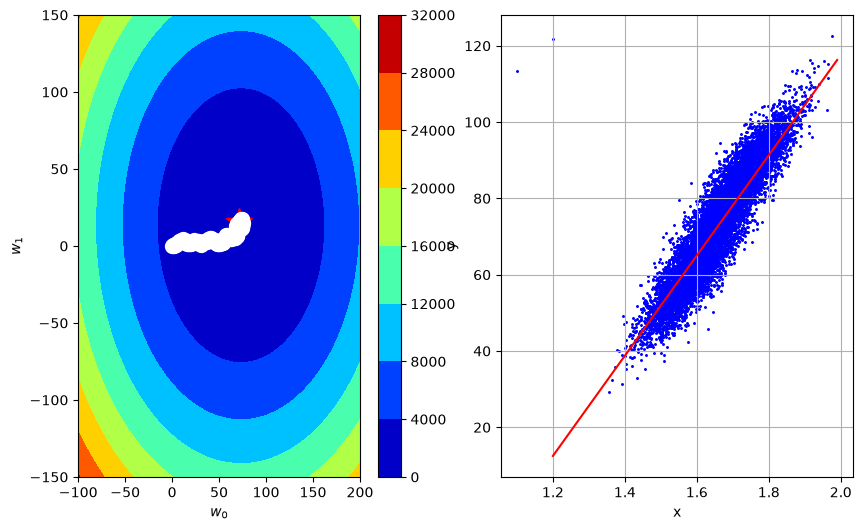

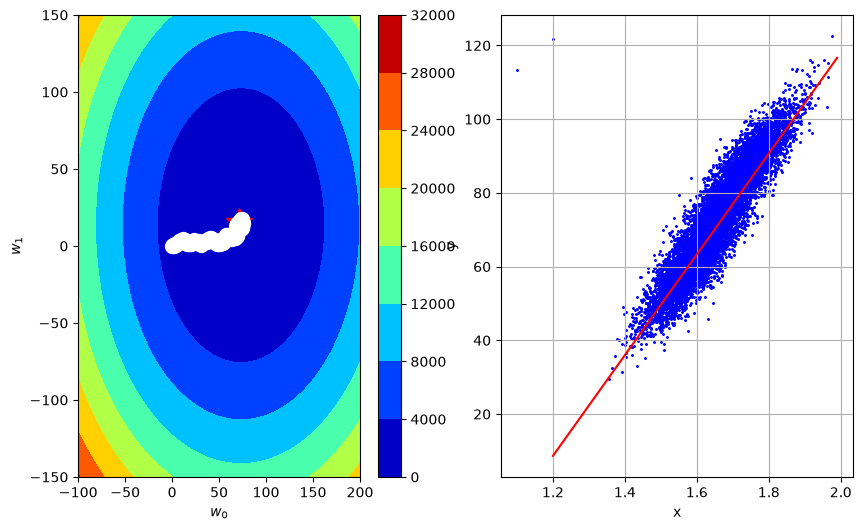

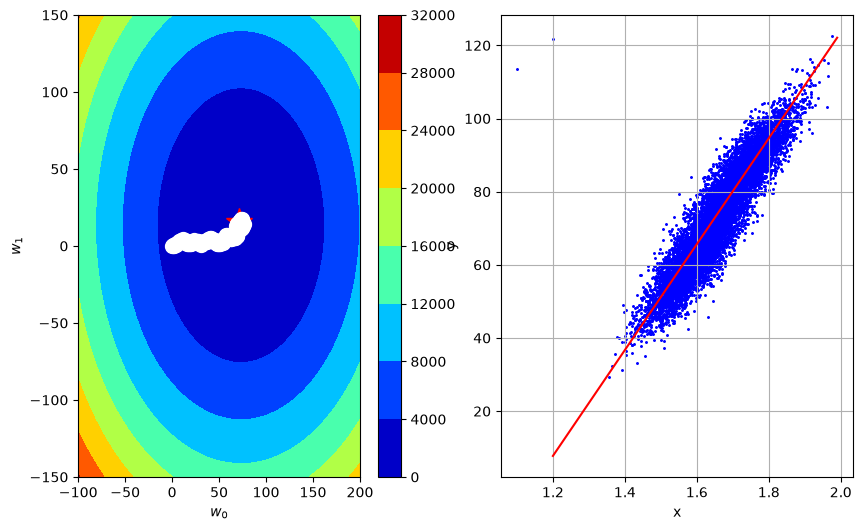

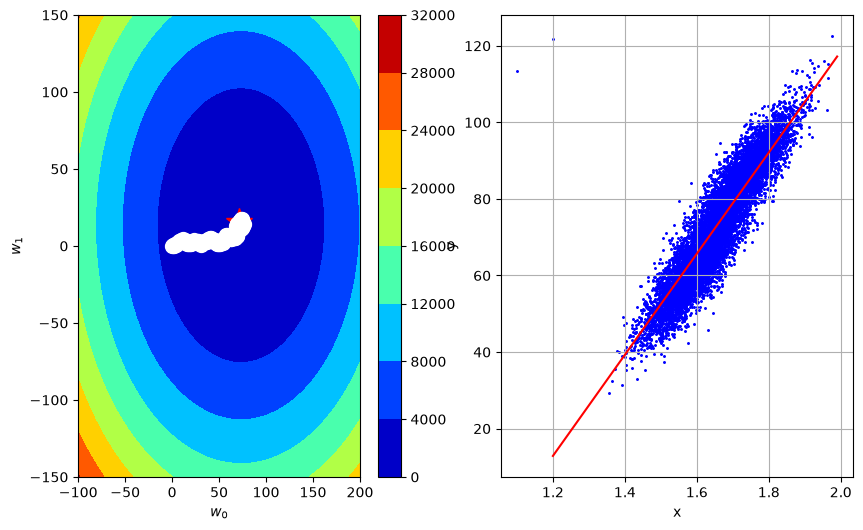

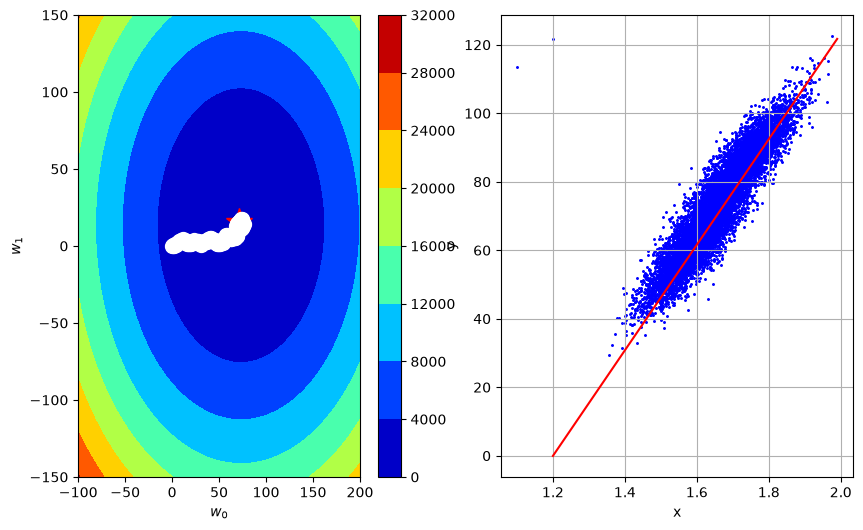

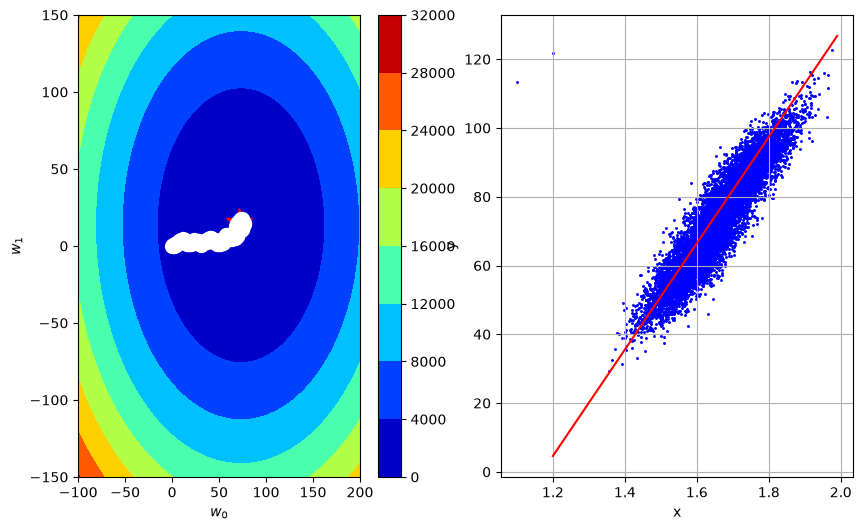

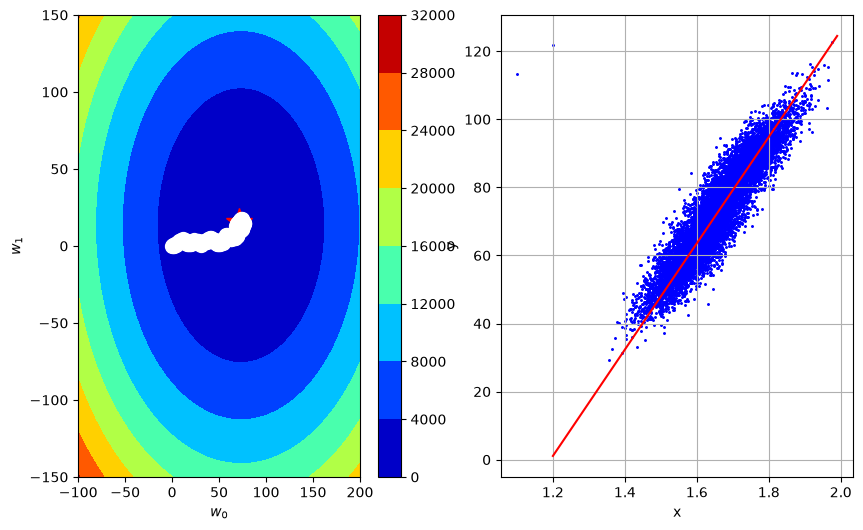

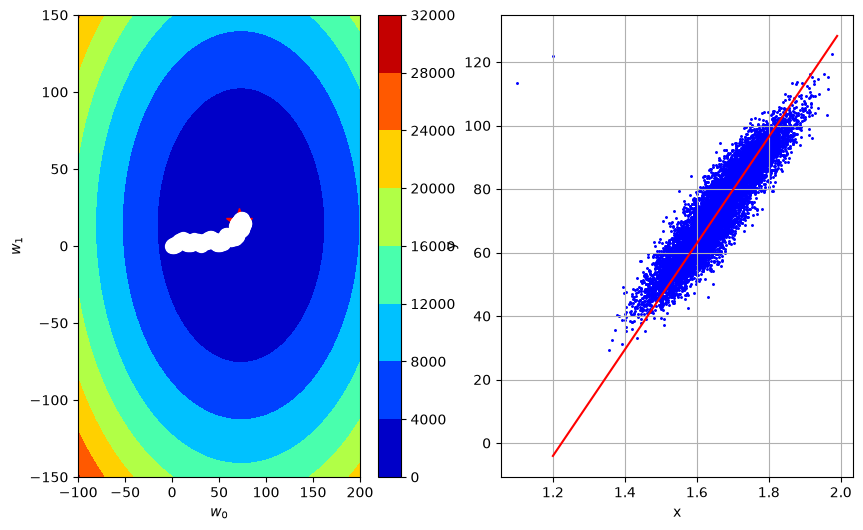

In [73]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subsgd_losses,
        subsgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subsgd_ws)))